In [1]:
total_qubits_before_transpile_reference = [3, 3, 3, 3, 3, 5, 5, 5, 10, 10, 10]
total_depth_before_transpile_reference = [3, 5, 7, 15, 30, 5, 15, 30, 10, 15, 30]
total_gates_before_transpile_reference = [6, 8, 10, 18, 33, 10, 20, 35, 20, 25, 40]

total_gates_after_transpile_mine = [44, 47, 75, 123, 281, 103, 246, 446, 416, 452, 870]
total_gates_after_transpile_qiskit = [25, 24, 24, 93, 158, 52, 112, 180, 114, 104, 245]

total_depth_after_transpile_mine = [29, 31, 47, 76, 169, 61, 144, 260, 242, 263, 502]
total_depth_after_transpile_qiskit = [18, 16, 17, 62, 111, 31, 61, 97, 51, 56, 136]

total_transpilation_time_mine = [2.1349, 1.974, 1.9254, 2.0533, 1.9855, 1.9958, 1.9409, 2.0177, 1.9625, 2.1666, 2.118]
total_transpilation_time_qiskit = [0.0206, 0.0498, 0.041, 0.0453, 0.0461, 0.0415, 0.0448, 0.046, 0.0485, 0.0482, 0.0595]

mean_errors_after_10_hardware_runs_mine = [0.100195313, 0.1, 0.10859375, 0.082714844, 0.159765625, 0.103515625, 0.234960938, 0.323535156, 0.290234375, 0.321484375, 0.621875]
mean_errors_after_10_hardware_runs_qiskit = [0.034082031, 0.047949219, 0.047363281, 0.074707031, 0.126464844, 0.070605469, 0.134375, 0.247558594, 0.209277344, 0.257128906, 0.415332031]

stat_analysis_results_mine_50_runs_simulator_mean = [0.019726563, 0.030527344, 0.043027344, 0.05625, 0.107558594, 0.041796875, 0.120625, 0.175371094, 0.134570313, 0.165351563, 0.328945313]
stat_analysis_results_mine_50_runs_simulator_std = [0.004238776, 0.005333891, 0.005518779, 0.007205417, 0.008999245, 0.006256101, 0.008653997, 0.013564154, 0.009985799, 0.012419541, 0.015344603]
stat_analysis_results_mine_50_runs_simulator_95ci = [0.0012, 0.0015, 0.0015, 0.0020, 0.0025, 0.0017, 0.0024, 0.0038, 0.0028, 0.0034, 0.0043]

stat_analysis_results_qiskit_50_runs_simulator_mean = [0.020722656, 0.036328125, 0.041601563, 0.051054688, 0.090996094, 0.046367188, 0.112167969, 0.160195313, 0.106191406, 0.12734375, 0.196367188]
stat_analysis_results_qiskit_50_runs_simulator_std = [0.004307028, 0.006079837, 0.006057837, 0.007012344, 0.008216344, 0.007075167, 0.008958885, 0.011690983, 0.008604419, 0.011790147, 0.014415915]
stat_analysis_results_qiskit_50_runs_simulator_95ci = [0.0012, 0.0017, 0.0017, 0.0019, 0.0023, 0.0020, 0.0025, 0.0032, 0.0024, 0.0033, 0.0040]


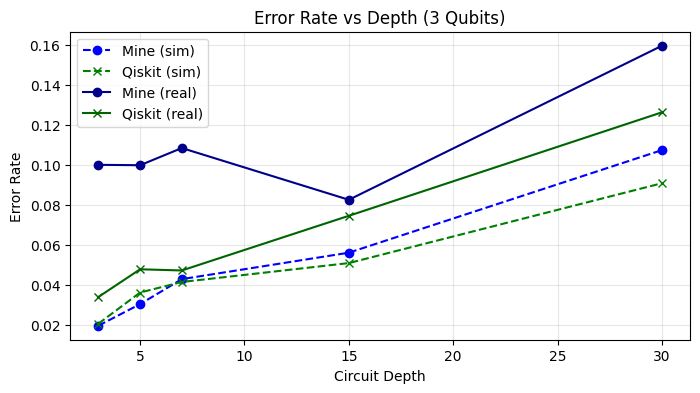

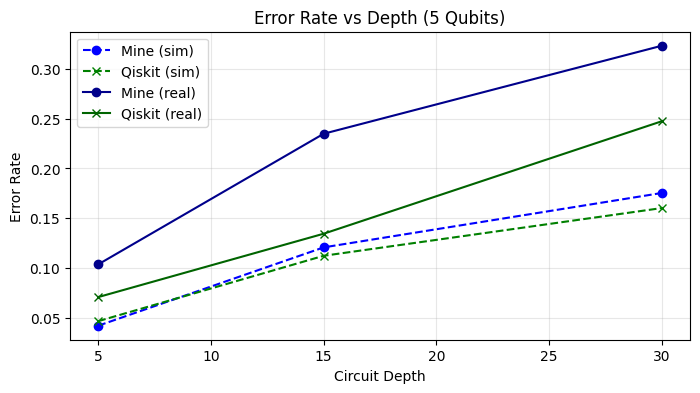

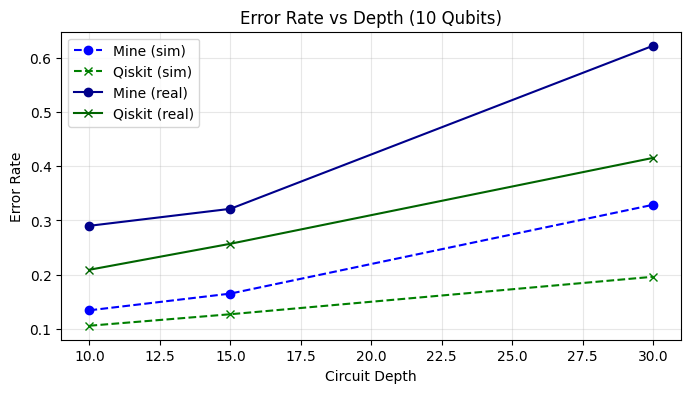

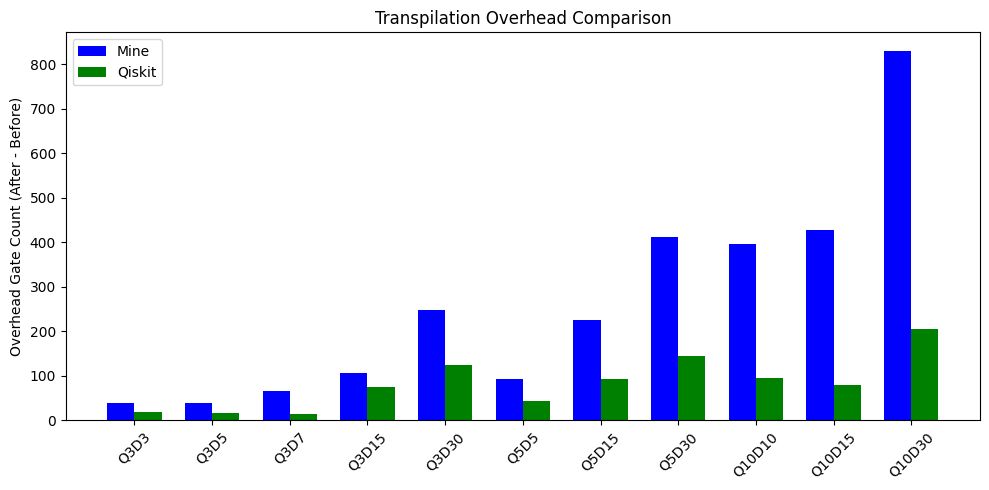

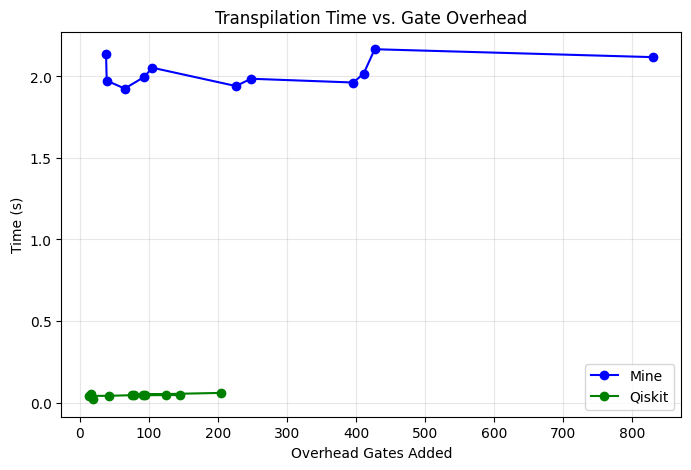

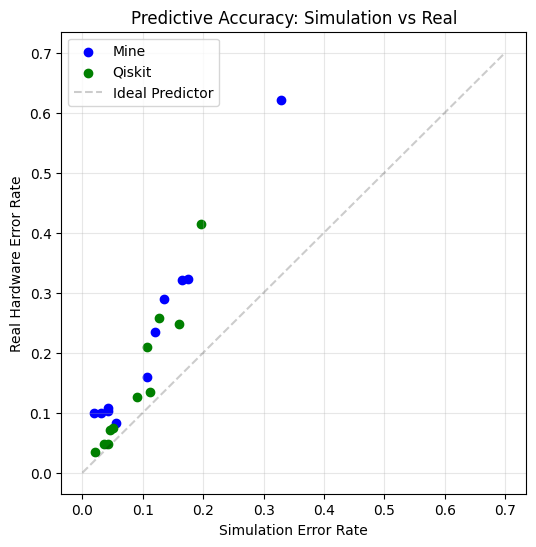

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Calculate the Overhead Gates (the actual "cost" added by transpilation)
overhead_gates_mine = [after - before for after, before in zip(total_gates_after_transpile_mine, total_gates_before_transpile_reference)]
overhead_gates_qiskit = [after - before for after, before in zip(total_gates_after_transpile_qiskit, total_gates_before_transpile_reference)]

configs = [f"Q{q}D{d}" for q, d in zip(total_qubits_before_transpile_reference, total_depth_before_transpile_reference)]

df = pd.DataFrame({
    'qubits': total_qubits_before_transpile_reference,
    'depth': total_depth_before_transpile_reference,
    'sim_mine': stat_analysis_results_mine_50_runs_simulator_mean,
    'sim_qiskit': stat_analysis_results_qiskit_50_runs_simulator_mean,
    'real_mine': mean_errors_after_10_hardware_runs_mine,
    'real_qiskit': mean_errors_after_10_hardware_runs_qiskit,
    'overhead_mine': overhead_gates_mine,
    'overhead_qiskit': overhead_gates_qiskit,
    'time_mine': total_transpilation_time_mine,
    'time_qiskit': total_transpilation_time_qiskit
})

# --- Graph 1: Error rate vs depth (multi-line) ---
unique_q = sorted(df['qubits'].unique())
for q in unique_q:
    subset = df[df['qubits'] == q].sort_values('depth')
    plt.figure(figsize=(8, 4))
    plt.plot(subset['depth'], subset['sim_mine'], 'o--', label='Mine (sim)', color='blue')
    plt.plot(subset['depth'], subset['sim_qiskit'], 'x--', label='Qiskit (sim)', color='green')
    plt.plot(subset['depth'], subset['real_mine'], 'o-', label='Mine (real)', color='darkblue')
    plt.plot(subset['depth'], subset['real_qiskit'], 'x-', label='Qiskit (real)', color='darkgreen')
    plt.title(f'Error Rate vs Depth ({q} Qubits)')
    plt.xlabel('Circuit Depth')
    plt.ylabel('Error Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Graph 2: Overhead Gate Count vs circuit configuration ---
plt.figure(figsize=(10, 5))
x_idx = np.arange(len(configs))
width = 0.35
plt.bar(x_idx - width/2, overhead_gates_mine, width, label='Mine', color='blue')
plt.bar(x_idx + width/2, overhead_gates_qiskit, width, label='Qiskit', color='green')
plt.xticks(x_idx, configs, rotation=45)
plt.ylabel('Overhead Gate Count (After - Before)')
plt.title('Transpilation Overhead Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# --- Graph 3: Transpilation time vs Overhead Gates ---
plt.figure(figsize=(8, 5))
# Using My Transpiler overhead for the X-axis sorting to visualize scaling
sort_idx = np.argsort(overhead_gates_mine)
plt.plot(np.array(overhead_gates_mine)[sort_idx], np.array(total_transpilation_time_mine)[sort_idx], 'o-', label='Mine', color='blue')
plt.plot(np.array(overhead_gates_qiskit)[sort_idx], np.array(total_transpilation_time_qiskit)[sort_idx], 'o-', label='Qiskit', color='green')
plt.xlabel('Overhead Gates Added')
plt.ylabel('Time (s)')
plt.title('Transpilation Time vs. Gate Overhead')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Graph 4: Simulation error vs real hardware error ---
plt.figure(figsize=(6, 6))
plt.scatter(df['sim_mine'], df['real_mine'], color='blue', label='Mine')
plt.scatter(df['sim_qiskit'], df['real_qiskit'], color='green', label='Qiskit')
plt.plot([0, 0.7], [0, 0.7], 'k--', alpha=0.2, label='Ideal Predictor')
plt.xlabel('Simulation Error Rate')
plt.ylabel('Real Hardware Error Rate')
plt.title('Predictive Accuracy: Simulation vs Real')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()